In [1]:
import os.path  as op
from os import listdir
import matplotlib
from matplotlib import pyplot as plt
import nilearn
import nibabel as nib
import numpy as np
import nilearn.plotting as nipl 
import nilearn.image as niim
import matplotlib as mpl

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']


In [2]:
def get_2ndlevel_spm(model, version, con, bids_folder):
    spm_file = op.join(bids_folder,'derivatives', 'spm', f'{model}-{version}_con_2ndlevels',f'2ndlevel_{model}-{version}_{con}','spmT_0001.nii')
    spm = nib.load(spm_file)
    return spm


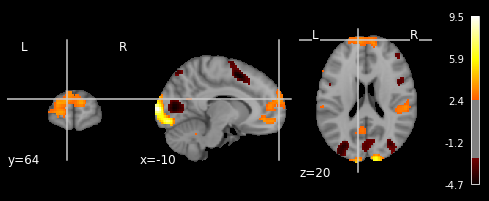

In [8]:
model = 'NLC'
version = 3
con = 'v2_ch'

anat_file = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz'
anat = nib.load(anat_file)

coords = [-10, 64, 20]
display = nipl.plot_anat(anat_img = anat, cut_coords = (coords[0], coords[1], coords[2]))
display.add_overlay(spm, threshold = 2.5, colorbar=True, cmap = mpl.colormaps['hot'])


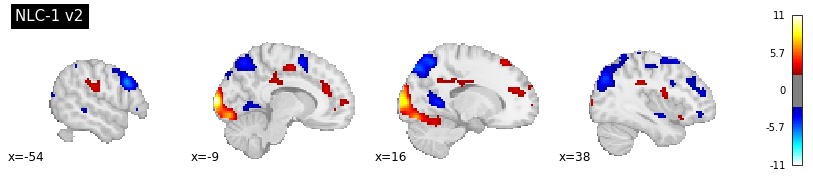

In [21]:
model = 'NLC'
version = '1'
contrast = 'v2'
spm= get_2ndlevel_spm(model=model, version=version, con=contrast, bids_folder=bids_folder)
nipl.plot_stat_map(spm,threshold = 2.5,  draw_cross=False, title=f'{model}-{version} {contrast}', display_mode='x', cut_coords =4 )


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


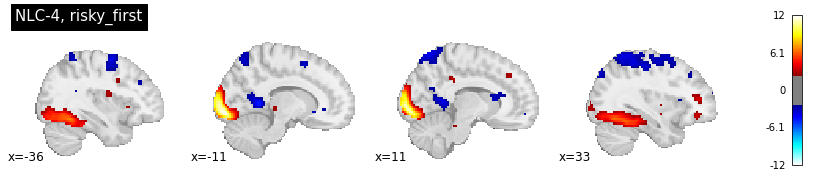

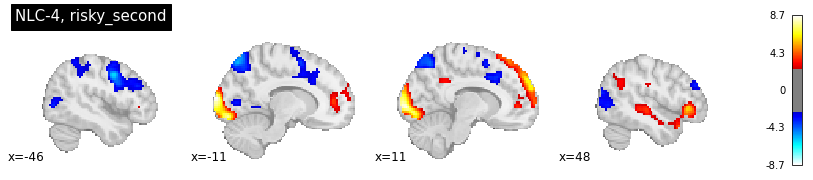

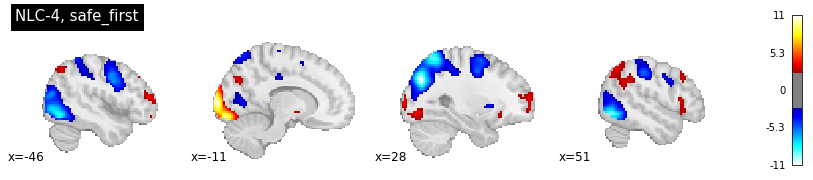

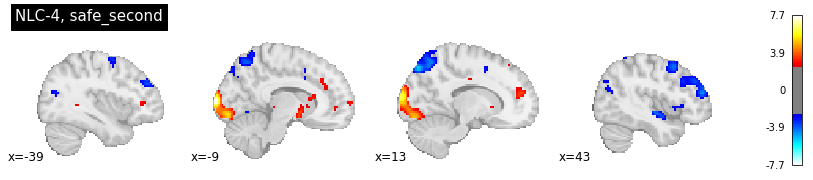

In [3]:
model = 'NLC'
version = '4'

model_folder = op.join(bids_folder,'derivatives', 'spm', f'{model}-{version}_con_2ndlevels')
if model == 'EU' or model=='EV' and version != '3b':
    cons = [f[14:] for f in listdir(model_folder)]
else:
    cons = [f[15:] for f in listdir(model_folder)]

for con in cons:
    spm= get_2ndlevel_spm(model=model, version=version, con=con, bids_folder=bids_folder)
    disp = nipl.plot_stat_map(spm,threshold = 2.5,  draw_cross=False, title=f'{model}-{version}, {con}', display_mode='x', cut_coords=4)
    out_file = op.join(bids_folder,'figures','spm_2ndlevels', f'{model}-{version}_{con}')
    disp.savefig(out_file ,dpi=199)


In [4]:
cons

['_v1_ch', '_v1_ch_dif', '_v1_unch', '_v2_ch', '_v2_ch_dif', '_v2_unch']

In [87]:
model = 'NLC'
version = '3'

model_folder = op.join(bids_folder,'derivatives', 'spm', f'{model}-{version}_con_2ndlevels')
if model == 'EU' or model =='EV':
    cons = [f[14:] for f in listdir(model_folder)]
elif model == 'NLC':
    cons = [f[15:] for f in listdir(model_folder)]

cons

['v1_ch', 'v1_ch_dif', 'v1_unch', 'v2_ch', 'v2_ch_dif', 'v2_unch']

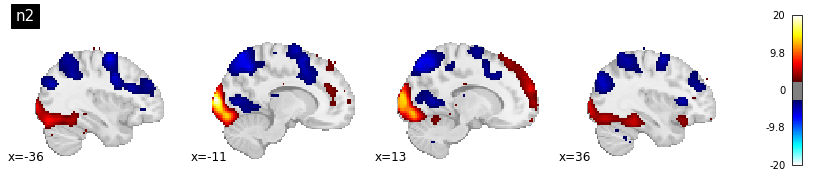

In [18]:
# pure numerosities
num = 2
con = f'n{num}'
model_n = 'pure num'
spm = nib.load(f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/spm/2ndlevel_num_{num}/spmT_0001.nii')
disp = nipl.plot_stat_map(spm,threshold = 2.5,  draw_cross=False, title=f'n{num}', display_mode='x', cut_coords=4)


In [34]:
model = 'NLC'
version = '3'
con =  'v2_ch'
spm= get_2ndlevel_spm(model=model, version=version, con=con, bids_folder=bids_folder)
model_n = f'{model}-{version}'

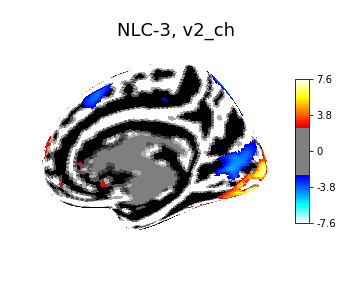

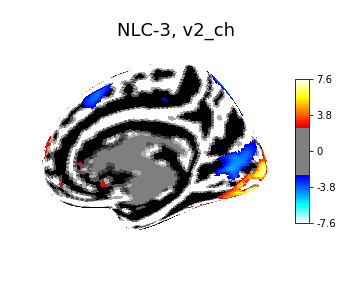

In [35]:
from nilearn import datasets, surface
fsaverage = datasets.fetch_surf_fsaverage()
curv_right = surface.load_surf_data(fsaverage.curv_right)
curv_right_sign = np.sign(curv_right)

texture = surface.vol_to_surf(spm, fsaverage.pial_right)

nipl.plot_surf_stat_map(surf_mesh= fsaverage.infl_right,stat_map= texture, 
    view='medial',
    hemi='right',
    title=f'{model_n}, {con}', colorbar=True,
    threshold=2.5, bg_map=curv_right_sign) # bg_map: Background image to be plotted on the mesh underneath the stat_map in greyscale

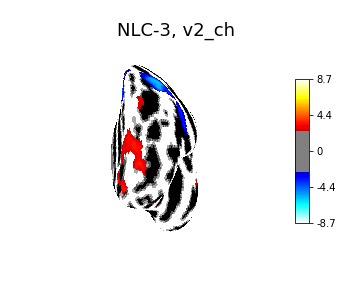

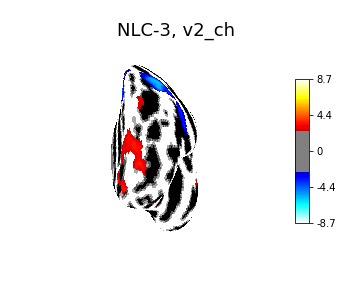

In [39]:
from nilearn import datasets, surface
fsaverage = datasets.fetch_surf_fsaverage()
curv_left = surface.load_surf_data(fsaverage.curv_left)
curv_left_sign = np.sign(curv_left)

texture = surface.vol_to_surf(spm, fsaverage.pial_left)

nipl.plot_surf_stat_map(surf_mesh= fsaverage.infl_left,stat_map= texture, 
    view='anterior',
    hemi='left',
    title=f'{model_n}, {con}', colorbar=True,
    threshold=2.5, bg_map=curv_left_sign) # bg_map: Background image to be plotted on the mesh underneath the stat_map in greyscale